# Setup A - Effective Sample Size for Static NIR Reflectance Measurement

Static powder bed, circular probe window, deterministic first-generation model

## Background

Setup A represents a static powder bed measured with a contact or near-contact diffuse reflectance NIR probe. In this configuration, powder motion is neglected during acquisition, so the optical interaction zone can be approximated from probe geometry and effective penetration depth.

Effective sample size matters because it links measured spectral response to how much material actually contributes to the signal. This directly influences interpretation, robustness, and representativity.

A static powder bed is conceptually the simplest setup because dynamic transport and re-sampling effects are absent in the first approximation. The remaining challenge is optical interaction geometry.

It is important to distinguish the geometric interaction volume from the true optical sensitivity distribution. Real diffuse reflectance sampling is non-uniform with depth and lateral position. This notebook starts with a cylindrical approximation to provide a clear first-order model for sensitivity analysis and order-of-magnitude understanding.

## Objective

Simulate sampled volume and sampled mass for a 5 mm circular probe as a function of effective penetration depth from 0.1 mm to 2.0 mm, and examine the influence of powder bulk density.

## Theory

For a circular probe window:

$$A_{probe} = \pi\left(\frac{D_{probe}}{2}\right)^2$$

First-generation sampled volume approximation:

$$V_{sample} \approx A_{probe}\,d_{pen}$$

Sampled mass approximation:

$$m_{sample} = \rho_{bulk}\,V_{sample}$$

Symbols and units:

- $D_{probe}$: probe window diameter [m]
- $A_{probe}$: probe area [m$^2$]
- $d_{pen}$: effective penetration depth [m]
- $\rho_{bulk}$: bulk density [kg/m$^3$]
- $V_{sample}$: sampled volume [m$^3$]
- $m_{sample}$: sampled mass [kg]

This is a first-generation geometric approximation. The true optical sensitivity distribution is not perfectly cylindrical.

## Assumptions

- static powder bed
- uniform bulk density
- circular probe window
- uniform effective penetration depth
- cylindrical optical interaction volume approximation
- no particle motion during acquisition
- no resampling
- no detailed radiative transfer model yet

## Input Parameters

Baseline and sweep configuration:

- baseline probe diameter: 5.0 mm
- penetration depth range: 0.1 mm to 2.0 mm (inclusive), step 0.1 mm
- Setup A bulk densities (discrete scenarios): 0.40, 0.50, 0.60 g/cm$^3$

Setup A examines only these three representative bulk-density cases for moderately light to moderately dense pharmaceutical powder beds/blends. The intent is scenario comparison, not continuous interpolation.

Internal calculations use SI units.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Baseline geometry (user-facing)
probe_diameter_mm = 5.0

# Penetration-depth sweep for Setup A (static bed)
penetration_depths_mm = np.arange(0.1, 2.0 + 0.001, 0.1)
penetration_depths_cm = penetration_depths_mm / 10.0

# Setup A discrete bulk-density scenarios
bulk_densities = np.array([0.4, 0.5, 0.6])
bulk_densities_g_cm3 = bulk_densities

# Compact input summary table
input_summary_df = pd.DataFrame(
    {
        "parameter": [
            "probe_diameter_mm",
            "penetration_depth_start_mm",
            "penetration_depth_end_mm",
            "penetration_depth_step_mm",
            "bulk_densities_g_cm3",
        ],
        "value": [
            probe_diameter_mm,
            penetration_depths_mm.min(),
            penetration_depths_mm.max(),
            0.1,
            ", ".join(f"{x:.2f}" for x in bulk_densities_g_cm3),
        ],
    }
)

input_summary_df

,parameter,value
0,probe_diameter_mm,5.0
1,penetration_depth_start_mm,0.1
2,penetration_depth_end_mm,2.0
3,penetration_depth_step_mm,0.1
4,bulk_densities_g_cm3,"0.40, 0.50, 0.60"


In [3]:
def mm_to_m(length_mm: float) -> float:
    "Convert millimeters to meters."
    return length_mm * 1e-3


def g_cm3_to_kg_m3(density_g_cm3: float) -> float:
    "Convert density from g/cm^3 to kg/m^3."
    return density_g_cm3 * 1000.0


def circular_probe_area_m2(probe_diameter_m: float) -> float:
    "Calculate circular probe area in m^2 from probe diameter in m."
    return np.pi * (probe_diameter_m / 2.0) ** 2


def sampled_volume_m3(probe_area_m2: float, penetration_depth_m: float) -> float:
    "Calculate sampled volume in m^3 using cylindrical approximation."
    return probe_area_m2 * penetration_depth_m


def sampled_mass_kg(bulk_density_kg_m3: float, volume_m3: float) -> float:
    "Calculate sampled mass in kg from bulk density and sampled volume."
    return bulk_density_kg_m3 * volume_m3

In [4]:
probe_diameter_m = mm_to_m(probe_diameter_mm)
probe_area_m2 = circular_probe_area_m2(probe_diameter_m)
illuminated_area_cm2 = probe_area_m2 * 1e4

rows = []
for penetration_depth_mm, penetration_depth_cm in zip(penetration_depths_mm, penetration_depths_cm):
    penetration_depth_m = mm_to_m(float(penetration_depth_mm))
    volume_m3 = sampled_volume_m3(probe_area_m2, penetration_depth_m)
    volume_mm3 = volume_m3 * 1e9
    sampled_volume_cm3 = illuminated_area_cm2 * penetration_depth_cm

    for bulk_density_g_cm3 in bulk_densities_g_cm3:
        bulk_density_kg_m3 = g_cm3_to_kg_m3(float(bulk_density_g_cm3))
        sampled_mass_g = bulk_density_g_cm3 * sampled_volume_cm3
        sampled_mass_mg = sampled_mass_g * 1000
        sampled_mass_kg = sampled_mass_g / 1000

        rows.append(
            {
                "setup": "A",
                "penetration_depth_mm": penetration_depth_mm,
                "penetration_depth_cm": penetration_depth_cm,
                "penetration_depth_m": penetration_depth_m,
                "bulk_density_g_cm3": bulk_density_g_cm3,
                "bulk_density_g_per_cm3": bulk_density_g_cm3,
                "bulk_density_kg_m3": bulk_density_kg_m3,
                "probe_diameter_mm": probe_diameter_mm,
                "probe_area_m2": probe_area_m2,
                "illuminated_area_cm2": illuminated_area_cm2,
                "sampled_volume_m3": volume_m3,
                "sampled_volume_mm3": volume_mm3,
                "sampled_volume_cm3": sampled_volume_cm3,
                "sampled_mass_kg": sampled_mass_kg,
                "sampled_mass_g": sampled_mass_g,
                "sampled_mass_mg": sampled_mass_mg,
                "effective_sample_size_g": sampled_mass_g,
                "effective_sample_size_mg": sampled_mass_mg,
            }
        )

results_df = pd.DataFrame(rows)

expected_depths_mm = np.round(np.arange(0.1, 2.0 + 0.001, 0.1), 10)
actual_depths_mm = np.round(np.sort(results_df["penetration_depth_mm"].unique()), 10)

assert np.array_equal(actual_depths_mm, expected_depths_mm)
assert results_df["bulk_density_g_cm3"].nunique() == 3
assert set(results_df["bulk_density_g_cm3"].unique()) == {0.4, 0.5, 0.6}

results_df

,setup,penetration_depth_mm,penetration_depth_cm,penetration_depth_m,bulk_density_g_cm3,bulk_density_g_per_cm3,bulk_density_kg_m3,probe_diameter_mm,probe_area_m2,illuminated_area_cm2,sampled_volume_m3,sampled_volume_mm3,sampled_volume_cm3,sampled_mass_kg,sampled_mass_g,sampled_mass_mg,effective_sample_size_g,effective_sample_size_mg
0,A,0.1,0.01,0.0001,0.4,0.4,400.0,5.0,0.00002,0.19635,1.963495e-09,1.963495,0.001963,7.853982e-07,0.000785,0.785398,0.000785,0.785398
1,A,0.1,0.01,0.0001,0.5,0.5,500.0,5.0,0.00002,0.19635,1.963495e-09,1.963495,0.001963,9.817477e-07,0.000982,0.981748,0.000982,0.981748
2,A,0.1,0.01,0.0001,0.6,0.6,600.0,5.0,0.00002,0.19635,1.963495e-09,1.963495,0.001963,1.178097e-06,0.001178,1.178097,0.001178,1.178097
3,A,0.2,0.02,0.0002,0.4,0.4,400.0,5.0,0.00002,0.19635,3.926991e-09,3.926991,0.003927,1.570796e-06,0.001571,1.570796,0.001571,1.570796
4,A,0.2,0.02,0.0002,0.5,0.5,500.0,5.0,0.00002,0.19635,3.926991e-09,3.926991,0.003927,1.963495e-06,0.001963,1.963495,0.001963,1.963495
5,A,0.2,0.02,0.0002,0.6,0.6,600.0,5.0,0.00002,0.19635,3.926991e-09,3.926991,0.003927,2.356194e-06,0.002356,2.356194,0.002356,2.356194
6,A,0.3,0.03,0.0003,0.4,0.4,400.0,5.0,0.00002,0.19635,5.890486e-09,5.890486,0.005890,2.356194e-06,0.002356,2.356194,0.002356,2.356194
7,A,0.3,0.03,0.0003,0.5,0.5,500.0,5.0,0.00002,0.19635,5.890486e-09,5.890486,0.005890,2.945243e-06,0.002945,2.945243,0.002945,2.945243
8,A,0.3,0.03,0.0003,0.6,0.6,600.0,5.0,0.00002,0.19635,5.890486e-09,5.890486,0.005890,3.534292e-06,0.003534,3.534292,0.003534,3.534292
9,A,0.4,0.04,0.0004,0.4,0.4,400.0,5.0,0.00002,0.19635,7.853982e-09,7.853982,0.007854,3.141593e-06,0.003142,3.141593,0.003142,3.141593


## Interpretation of the Simulation Table

Each row corresponds to one penetration depth and one bulk-density scenario for static Setup A. Effective sample size is treated as sampled mass from a static illuminated volume and computed as:

$${m}_{eff} \approx \rho_{bulk} \cdot A_{illum} \cdot d_{pen}$$

where the illuminated area is fixed by probe geometry and penetration depth is swept from 0.1 to 2.0 mm.

In [5]:
# Rounded preview for readability
results_display_df = results_df.copy()
results_display_df["penetration_depth_m"] = results_display_df["penetration_depth_m"].round(6)
results_display_df["probe_area_m2"] = results_display_df["probe_area_m2"].round(8)
results_display_df["sampled_volume_m3"] = results_display_df["sampled_volume_m3"].round(12)
results_display_df["sampled_volume_mm3"] = results_display_df["sampled_volume_mm3"].round(4)
results_display_df["sampled_mass_kg"] = results_display_df["sampled_mass_kg"].round(10)
results_display_df["sampled_mass_mg"] = results_display_df["sampled_mass_mg"].round(4)

results_display_df.head(20)

,setup,penetration_depth_mm,penetration_depth_cm,penetration_depth_m,bulk_density_g_cm3,bulk_density_g_per_cm3,bulk_density_kg_m3,probe_diameter_mm,probe_area_m2,illuminated_area_cm2,sampled_volume_m3,sampled_volume_mm3,sampled_volume_cm3,sampled_mass_kg,sampled_mass_g,sampled_mass_mg,effective_sample_size_g,effective_sample_size_mg
0,A,0.1,0.01,0.0001,0.4,0.4,400.0,5.0,0.00002,0.19635,1.963000e-09,1.9635,0.001963,7.854000e-07,0.000785,0.7854,0.000785,0.785398
1,A,0.1,0.01,0.0001,0.5,0.5,500.0,5.0,0.00002,0.19635,1.963000e-09,1.9635,0.001963,9.817000e-07,0.000982,0.9817,0.000982,0.981748
2,A,0.1,0.01,0.0001,0.6,0.6,600.0,5.0,0.00002,0.19635,1.963000e-09,1.9635,0.001963,1.178100e-06,0.001178,1.1781,0.001178,1.178097
3,A,0.2,0.02,0.0002,0.4,0.4,400.0,5.0,0.00002,0.19635,3.927000e-09,3.9270,0.003927,1.570800e-06,0.001571,1.5708,0.001571,1.570796
4,A,0.2,0.02,0.0002,0.5,0.5,500.0,5.0,0.00002,0.19635,3.927000e-09,3.9270,0.003927,1.963500e-06,0.001963,1.9635,0.001963,1.963495
5,A,0.2,0.02,0.0002,0.6,0.6,600.0,5.0,0.00002,0.19635,3.927000e-09,3.9270,0.003927,2.356200e-06,0.002356,2.3562,0.002356,2.356194
6,A,0.3,0.03,0.0003,0.4,0.4,400.0,5.0,0.00002,0.19635,5.890000e-09,5.8905,0.005890,2.356200e-06,0.002356,2.3562,0.002356,2.356194
7,A,0.3,0.03,0.0003,0.5,0.5,500.0,5.0,0.00002,0.19635,5.890000e-09,5.8905,0.005890,2.945200e-06,0.002945,2.9452,0.002945,2.945243
8,A,0.3,0.03,0.0003,0.6,0.6,600.0,5.0,0.00002,0.19635,5.890000e-09,5.8905,0.005890,3.534300e-06,0.003534,3.5343,0.003534,3.534292
9,A,0.4,0.04,0.0004,0.4,0.4,400.0,5.0,0.00002,0.19635,7.854000e-09,7.8540,0.007854,3.141600e-06,0.003142,3.1416,0.003142,3.141593


## Plot 1: Sampled Volume vs Penetration Depth

This plot shows the geometric sampled volume as a function of penetration depth. In this model, sampled volume does not depend on bulk density.

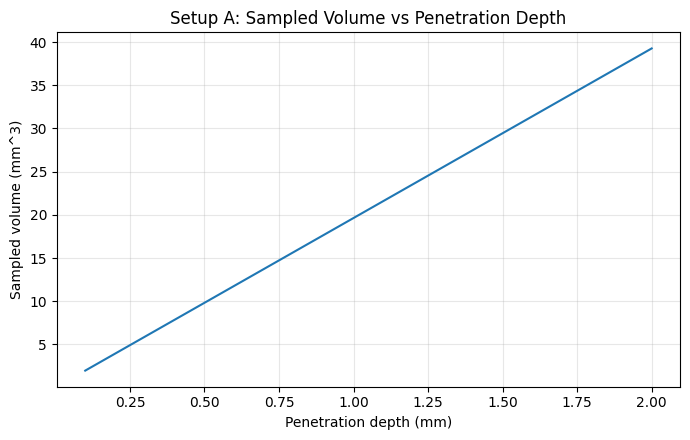

In [6]:
volume_vs_depth_df = (
    results_df[["penetration_depth_mm", "sampled_volume_mm3"]]
    .drop_duplicates()
    .sort_values("penetration_depth_mm")
)

fig_setup_a_volume, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(volume_vs_depth_df["penetration_depth_mm"], volume_vs_depth_df["sampled_volume_mm3"])
ax.set_xlabel("Penetration depth (mm)")
ax.set_ylabel("Sampled volume (mm^3)")
ax.set_title("Setup A: Sampled Volume vs Penetration Depth")
ax.grid(True, alpha=0.3)
fig_setup_a_volume.tight_layout()
plt.show()


## Plot 2: Effective Sample Size vs Light Penetration Depth

Setup A assumes a static powder bed. Effective sample size is approximated as bulk density x illuminated area x penetration depth, so the plotted quantity is the estimated sampled mass contributing to the reflectance measurement. Penetration depth is varied from 0.1 to 2.0 mm to examine sensitivity to optical sampling depth, and three bulk-density scenarios (0.4, 0.5, 0.6 g/cm$^3$) represent lighter to denser powder beds.

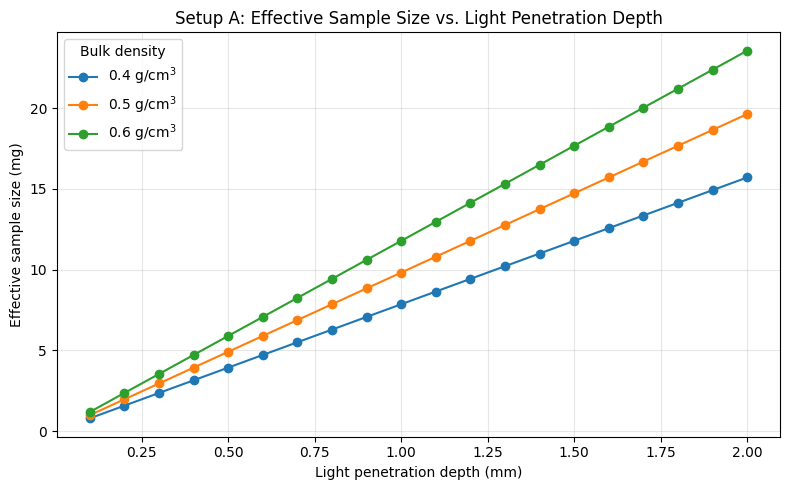

,setup,bulk_density_g_per_cm3,penetration_depth_mm,penetration_depth_cm,illuminated_area_cm2,sampled_volume_cm3,effective_sample_size_g,effective_sample_size_mg
0,A,0.4,0.1,0.01,0.19635,0.001963,0.000785,0.785398
1,A,0.5,0.1,0.01,0.19635,0.001963,0.000982,0.981748
2,A,0.6,0.1,0.01,0.19635,0.001963,0.001178,1.178097
3,A,0.4,0.2,0.02,0.19635,0.003927,0.001571,1.570796
4,A,0.5,0.2,0.02,0.19635,0.003927,0.001963,1.963495
5,A,0.6,0.2,0.02,0.19635,0.003927,0.002356,2.356194
6,A,0.4,0.3,0.03,0.19635,0.005890,0.002356,2.356194
7,A,0.5,0.3,0.03,0.19635,0.005890,0.002945,2.945243
8,A,0.6,0.3,0.03,0.19635,0.005890,0.003534,3.534292
9,A,0.4,0.4,0.04,0.19635,0.007854,0.003142,3.141593


In [7]:
df_setup_A = results_df.copy()

fig_setup_a_effective_mass, ax = plt.subplots(figsize=(8, 5))
for rho in bulk_densities:
    subset = (
        df_setup_A[df_setup_A["bulk_density_g_per_cm3"] == rho]
        .sort_values("penetration_depth_mm")
    )
    ax.plot(
        subset["penetration_depth_mm"],
        subset["effective_sample_size_mg"],
        marker="o",
        label=f"{rho:.1f} g/cm$^3$",
    )

ax.set_xlabel("Light penetration depth (mm)")
ax.set_ylabel("Effective sample size (mg)")
ax.set_title("Setup A: Effective Sample Size vs. Light Penetration Depth")
ax.legend(title="Bulk density")
ax.grid(True, alpha=0.3)
fig_setup_a_effective_mass.tight_layout()
plt.show()

df_setup_A[[
    "setup",
    "bulk_density_g_per_cm3",
    "penetration_depth_mm",
    "penetration_depth_cm",
    "illuminated_area_cm2",
    "sampled_volume_cm3",
    "effective_sample_size_g",
    "effective_sample_size_mg",
]].head(12)


## Results Interpretation

- effective sample size (sampled mass) scales linearly with penetration depth when illuminated area is fixed
- effective sample size increases with bulk density at any fixed penetration depth
- three density curves (0.40, 0.50, 0.60 g/cm$^3$) provide discrete scenario comparison for static Setup A
- this remains a geometric first approximation rather than a full optical transport model

## Practical Implications

- uncertainty in penetration depth strongly affects estimated effective sample size
- bulk density matters when converting interaction volume to sampled mass
- this framework is useful for comparing powders and probe setups

## Limitations

- true photon sampling distribution is non-uniform
- penetration depth is an effective parameter, not a sharp boundary
- bulk density may vary with compaction and handling
- particle-level sampling statistics are not yet included
- no correction factor for optical weighting yet

## Next logical extensions

- interaction volume correction factor
- particle count estimation
- sensitivity analysis for probe diameter
- uncertainty bands for penetration depth
- non-uniform optical weighting functions

## Export and Reporting

This export section writes timestamped CSV, PNG, JSON, and Word outputs into the setup-specific `reports/` folder. `python-docx` and `nbformat` are required for Word export with Markdown rendering.

In [8]:

from pathlib import Path
import importlib
import sys

project_root = Path(r"C:\Users\Erik\Documents\Projects\EFS")
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import src.reporting_utils as reporting_utils
reporting_utils = importlib.reload(reporting_utils)

build_word_report = reporting_utils.build_word_report
create_run_directory = reporting_utils.create_run_directory
save_dataframes_dict = reporting_utils.save_dataframes_dict
save_figures_dict = reporting_utils.save_figures_dict
write_metadata_json = reporting_utils.write_metadata_json

setup_name = "setup_a"
notebook_filename = "setup_A_static_effective_sample_size.ipynb"
notebook_path = project_root / "notebooks" / notebook_filename
report_filename = "setup_a_report.docx"

timestamp, run_dir = create_run_directory(project_root, setup_name)

summary_table_df = (
    results_df.groupby("bulk_density_g_cm3", as_index=False)
    .agg(
        penetration_depth_min_mm=("penetration_depth_mm", "min"),
        penetration_depth_max_mm=("penetration_depth_mm", "max"),
        sampled_volume_min_mm3=("sampled_volume_mm3", "min"),
        sampled_volume_max_mm3=("sampled_volume_mm3", "max"),
        effective_sample_size_min_mg=("effective_sample_size_mg", "min"),
        effective_sample_size_max_mg=("effective_sample_size_mg", "max"),
    )
)

dataframes_to_save = {
    "results_full": results_df,
    "summary_table": summary_table_df,
    "input_summary": input_summary_df,
}
figures_to_save = {
    "plot_01_sampled_volume_vs_penetration_depth": globals().get("fig_setup_a_volume"),
    "plot_02_effective_sample_size_vs_penetration_depth": globals().get("fig_setup_a_effective_mass"),
}

csv_files = save_dataframes_dict(dataframes_to_save, run_dir)
png_files = save_figures_dict(figures_to_save, run_dir, dpi=300)

parameter_summary = {
    "Probe diameter (mm)": probe_diameter_mm,
    "Penetration depth range (mm)": f"{penetration_depths_mm.min():.1f} to {penetration_depths_mm.max():.1f}",
    "Penetration depth step (mm)": 0.1,
    "Bulk densities (g/cm^3)": [float(x) for x in bulk_densities_g_cm3],
}
purpose_text = (
    "Setup A estimates static optical sampling mass for a fixed circular probe over a penetration-depth sweep "
    "and compares three representative bulk-density scenarios."
)
assumptions_text = (
    "Static powder bed, fixed illuminated area from probe geometry, uniform bulk density within each scenario, "
    "and a single effective penetration depth used as a first-order optical volume approximation."
)
metadata = {
    "setup_name": setup_name,
    "timestamp": timestamp,
    "notebook_filename": notebook_filename,
    "report_filename": report_filename,
    "csv_files": csv_files,
    "png_files": png_files,
    "key_parameters": parameter_summary,
}
write_metadata_json(metadata, run_dir / "metadata.json")

build_word_report(
    report_title="Setup A Effective Sample Size Report",
    setup_name=setup_name,
    timestamp=timestamp,
    run_dir=run_dir,
    notebook_path=notebook_path,
    purpose_text=purpose_text,
    assumptions_text=assumptions_text,
    parameter_summary=parameter_summary,
    csv_filenames=csv_files,
    figure_filenames=png_files,
    output_filename=report_filename,
)

print(f"Report run directory: {run_dir}")


Report run directory: C:\Users\Erik\Documents\Projects\EFS\reports\setup_a\20260315_213602
